# Retail Sales Performance Analysis

## Executive Summary

This project analyzes retail transaction-line data to understand sales performance across products, categories, regions, promotions, and time.

The analysis evaluates data quality, revenue concentration, unit demand, promotion activity, sales trends, and order-to-ship timing. The goal is to turn raw transaction records into insights that can support inventory planning, regional prioritization, promotional evaluation, and fulfilment monitoring.

### Scope

The dataset contains 32,040 transaction-line records and 17 fields covering product attributes, order dates, shipment dates, regions, quantities, prices, sales, discounts, taxes, and freight.

### Key outcomes

This analysis will identify:

- Revenue-leading categories, subcategories, and products.
- High-demand products based on units sold.
- Regions contributing the largest share of sales revenue and transaction activity.
- Promotion performance using units sold, sales revenue, and discount amounts.
- Monthly and yearly sales patterns within the available data period.
- Order-to-ship timing and shipment timing relative to due dates.

## 1. Import Libraries

This project uses Python libraries for data manipulation, visualization, and exploratory analysis.

The primary libraries include:

- Pandas for data manipulation and analysis.
- NumPy for numerical operations.
- Matplotlib for data visualization.
- Seaborn for statistical graphics.
- Datetime utilities for date-related analysis.

The libraries are imported below.

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
from scipy.stats import kruskal, f_oneway, spearmanr


In [8]:
from pathlib import Path

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.size"] = 11

## 2. Load Dataset

The retail sales dataset is loaded into the analysis environment for exploration and business analysis.

The dataset contains information related to:

- Sales transactions
- Products and categories
- Pricing and discounts
- Regional performance
- Shipping activities
- Order dates and delivery dates

After loading the dataset, an initial inspection is performed to verify that the data has been imported successfully.

In [60]:
from pathlib import Path
import pandas as pd

possible_paths = [
    Path("../data/raw/Retail.csv"),  # Notebook opened from notebooks/
    Path("data/raw/Retail.csv"),     # Notebook run from project root
]

DATA_PATH = next(
    (path for path in possible_paths if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Retail.csv was not found.\n"
        "Expected one of these locations:\n"
        "- data/raw/Retail.csv\n"
        "- ../data/raw/Retail.csv\n\n"
        "Copy the dataset into the project's data/raw folder."
    )

df = pd.read_csv(DATA_PATH)

print(f"Loaded data from: {DATA_PATH.resolve()}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()

Loaded data from: C:\Users\DELL\projects\retail-sales-performance-analysis\data\raw\Retail.csv
Shape: 32,040 rows × 17 columns


,OrderNumber,ProductName,Color,Category,Subcategory,ListPrice,Orderdate,Duedate,Shipdate,PromotionName,SalesRegion,OrderQuantity,UnitPrice,SalesAmount,DiscountAmount,TaxAmount,Freight
0,SO43843,"Mountain-100 Silver, 48",Silver,Bikes,Mountain Bikes,3399.9900,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,2039.9940,4079.9880,0.0,326.3990,101.9997
1,SO43843,"Mountain-100 Black, 48",Black,Bikes,Mountain Bikes,3374.9900,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,2024.9940,4049.9880,0.0,323.9990,101.2497
2,SO43843,"HL Mountain Frame - Silver, 46",Silver,Components,Mountain Frames,1204.3248,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,722.5949,1445.1898,0.0,115.6152,36.1297
3,SO43843,"Mountain-100 Black, 44",Black,Bikes,Mountain Bikes,NaN,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,5,2024.9940,10124.9700,0.0,809.9976,253.1243
4,SO43843,"HL Mountain Frame - Silver, 38",Silver,Components,Mountain Frames,1204.3248,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,722.5949,1445.1898,0.0,115.6152,36.1297


## 3. Business Questions

The analysis aims to answer the following questions.

### Product Performance

1. Which products generate the highest sales revenue?
2. Which product categories contribute the most revenue?
3. Which products have the highest sales volume?

### Regional Performance

4. Which sales regions contribute the most revenue?
5. Are there significant differences in sales performance across regions?

### Promotion Analysis

6. How do discounts affect sales performance?
7. Which products receive the largest discounts?

### Time-Series Analysis

8. How do sales vary over time?
9. Are there observable seasonal patterns?

### Operational Analysis

10. What is the average order processing time?
11. Are there delays between order, due, and shipment dates?

---

## 4. Dataset Overview

### Dataset Description

The dataset contains retail transaction records including product information, sales metrics, customer orders, shipping details, and promotional discounts.

**Data Dictionary**
| Column         | Description             |
| -------------- | ----------------------- |
| OrderDate      | Date order was placed   |
| DueDate        | Expected delivery date  |
| ShipDate       | Actual shipment date    |
| Product        | Product sold            |
| Category       | Product category        |
| Subcategory    | Product subcategory     |
| SalesRegion    | Geographic sales region |
| OrderQuantity  | Quantity sold           |
| ListPrice      | Original product price  |
| UnitPrice      | Actual selling price    |
| SalesAmount    | Revenue generated       |
| DiscountAmount | Discount applied        |
| TaxAmount      | Tax charged             |
| Freight        | Shipping cost           |


### Key Data Areas

- Product information
- Sales transactions
- Regional performance
- Pricing and discounts
- Shipping and delivery dates
- Revenue-related metrics

## Initial Dataset Inspection

The dataset was reviewed to understand:

- Number of records and features
- Data types
- Missing values
- Potential inconsistencies
- Overall structure of the dataset

---

In [11]:
df.head()

,OrderNumber,ProductName,Color,Category,Subcategory,ListPrice,Orderdate,Duedate,Shipdate,PromotionName,SalesRegion,OrderQuantity,UnitPrice,SalesAmount,DiscountAmount,TaxAmount,Freight
0,SO43843,"Mountain-100 Silver, 48",Silver,Bikes,Mountain Bikes,3399.9900,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,2039.9940,4079.9880,0.0,326.3990,101.9997
1,SO43843,"Mountain-100 Black, 48",Black,Bikes,Mountain Bikes,3374.9900,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,2024.9940,4049.9880,0.0,323.9990,101.2497
2,SO43843,"HL Mountain Frame - Silver, 46",Silver,Components,Mountain Frames,1204.3248,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,722.5949,1445.1898,0.0,115.6152,36.1297
3,SO43843,"Mountain-100 Black, 44",Black,Bikes,Mountain Bikes,NaN,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,5,2024.9940,10124.9700,0.0,809.9976,253.1243
4,SO43843,"HL Mountain Frame - Silver, 38",Silver,Components,Mountain Frames,1204.3248,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,722.5949,1445.1898,0.0,115.6152,36.1297


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32040 entries, 0 to 32039
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderNumber     32040 non-null  object 
 1   ProductName     32040 non-null  object 
 2   Color           29073 non-null  object 
 3   Category        32040 non-null  object 
 4   Subcategory     32040 non-null  object 
 5   ListPrice       32032 non-null  float64
 6   Orderdate       32040 non-null  object 
 7   Duedate         32040 non-null  object 
 8   Shipdate        32040 non-null  object 
 9   PromotionName   32040 non-null  object 
 10  SalesRegion     32025 non-null  object 
 11  OrderQuantity   32026 non-null  object 
 12  UnitPrice       32040 non-null  float64
 13  SalesAmount     32040 non-null  float64
 14  DiscountAmount  32040 non-null  float64
 15  TaxAmount       32040 non-null  float64
 16  Freight         32040 non-null  float64
dtypes: float64(6), object(11)
memor

In [13]:
df.describe()

,ListPrice,UnitPrice,SalesAmount,DiscountAmount,TaxAmount,Freight
count,32032.000000,32040.000000,32040.000000,32040.00000,32040.000000,32040.000000
mean,714.663419,424.122103,1299.023131,8.15285,103.921849,32.475594
std,851.623778,506.799303,2153.316625,78.40708,172.265331,53.832916
min,2.290000,1.328200,1.374000,0.00000,0.109900,0.034400
25%,54.990000,32.994000,125.964000,0.00000,10.077100,3.149100
50%,337.220000,202.332000,445.410000,0.00000,35.632800,11.135300
75%,1079.990000,647.994000,1457.820000,0.00000,116.625600,36.445500
max,3578.270000,2146.962000,27893.619000,4005.23760,2231.489500,697.340500


## 5. Data Quality Assessment

Before conducting the analysis, the dataset was assessed for quality and reliability.

## Assessment Areas

### Missing Values

Missing values were identified and evaluated to determine their potential impact on the analysis.

### Duplicate Records

Duplicate observations were checked to prevent inflated sales calculations.

### Data Types

Variables were reviewed to ensure they were stored using appropriate data types.

### Data Consistency

Columns were examined for inconsistent formatting, invalid values, and unusual entries.

### Outlier Detection

Extreme values were investigated to determine whether they represented valid business events or data quality issues.

---

In [14]:
quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing_pct", ascending=False)

quality_summary

,data_type,missing_count,missing_pct,unique_values
Color,object,2967,9.26,8
SalesRegion,object,15,0.05,10
OrderQuantity,object,14,0.04,38
ListPrice,float64,8,0.02,103
OrderNumber,object,0,0.00,1871
TaxAmount,float64,0,0.00,1271
DiscountAmount,float64,0,0.00,382
SalesAmount,float64,0,0.00,1271
UnitPrice,float64,0,0.00,214
Shipdate,object,0,0.00,17


In [15]:
# Check for duplicates
df_duplicates_check = df.duplicated().sum()
df_duplicates_check

0

In [16]:
df.dtypes

OrderNumber        object
ProductName        object
Color              object
Category           object
Subcategory        object
ListPrice         float64
Orderdate          object
Duedate            object
Shipdate           object
PromotionName      object
SalesRegion        object
OrderQuantity      object
UnitPrice         float64
SalesAmount       float64
DiscountAmount    float64
TaxAmount         float64
Freight           float64
dtype: object

### Data quality observations

- `Color` has the highest missingness at approximately 9.26%. Because colour is not required for the main revenue, regional, promotion, or fulfilment analyses, missing values will be labelled as `Unknown` rather than assigned to a specific colour.
- `SalesRegion` and `OrderQuantity` each have fewer than 0.1% missing values. Rows missing either field will be removed because the fields are required for regional and demand analyses.
- `ListPrice` has eight missing values. It will not be replaced with zero because zero would imply a free product. Where possible, missing prices will be imputed with the median price of the same product.
- The dataset has no exact duplicate rows. This does not mean every row is a unique order: the data is at transaction-line level, and one `OrderNumber` can contain multiple product lines.

# 6. Data Cleaning and Preparation

Data preparation ensures that the dataset is suitable for analysis.

The preparation process includes:

- Handling missing values
- Correcting data types
- Creating derived variables
- Preparing date fields
- Validating cleaned data

---

In [17]:
# Preserve the raw dataset
df_raw = df.copy()

# Standardize column names for Python readability
df = df.rename(columns={
    "Orderdate": "OrderDate",
    "Duedate": "DueDate",
    "Shipdate": "ShipDate"
})

# Treat categorical missing values transparently
df["Color"] = df["Color"].fillna("Unknown")

# Convert quantity to numeric; invalid values, including string "Nan", become actual NaN
df["OrderQuantity"] = pd.to_numeric(df["OrderQuantity"], errors="coerce")

# Convert price fields to numeric
numeric_columns = [
    "ListPrice", "UnitPrice", "SalesAmount",
    "DiscountAmount", "TaxAmount", "Freight"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Parse all dates; format='mixed' handles the slash and hyphen date styles
for column in ["OrderDate", "DueDate", "ShipDate"]:
    df[column] = pd.to_datetime(df[column], format="mixed", errors="coerce")

# Impute missing list prices from the same product, if possible
df["ListPrice"] = (
    df.groupby("ProductName")["ListPrice"]
      .transform(lambda s: s.fillna(s.median()))
)

# Remove rows required for regional and quantity analyses
rows_before = len(df)

df = df.dropna(subset=[
    "SalesRegion", "OrderQuantity", "OrderDate", "DueDate", "ShipDate"
]).copy()

df["OrderQuantity"] = df["OrderQuantity"].astype(int)

rows_after = len(df)
rows_removed = rows_before - rows_after

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {rows_after:,}")
print(f"Rows removed: {rows_removed:,}")

Rows before cleaning: 32,040
Rows after cleaning: 32,009
Rows removed: 31


In [18]:
cleaning_check = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "data_type": df.dtypes.astype(str)
})

cleaning_check

,missing_count,data_type
OrderNumber,0,object
ProductName,0,object
Color,0,object
Category,0,object
Subcategory,0,object
ListPrice,0,float64
OrderDate,0,datetime64[ns]
DueDate,0,datetime64[ns]
ShipDate,0,datetime64[ns]
PromotionName,0,object


In [19]:
# Sales and promotional discount metrics
# GrossListValue is useful for price-list analysis, but promotional discount
# analysis is based on the observed UnitPrice plus the separate DiscountAmount.
df["GrossListValue"] = df["ListPrice"] * df["OrderQuantity"]

df["GrossAtUnitPrice"] = df["UnitPrice"] * df["OrderQuantity"]

df["PromoDiscountRate"] = np.where(
    (df["GrossAtUnitPrice"] + df["DiscountAmount"]) > 0,
    df["DiscountAmount"] /
    (df["GrossAtUnitPrice"] + df["DiscountAmount"]),
    np.nan
)

# Keep DiscountRate as a legacy/list-price comparison metric
df["DiscountRate"] = np.where(
    df["GrossListValue"] > 0,
    df["DiscountAmount"] / df["GrossListValue"],
    np.nan
)

# Operational metrics
df["OrderToShipDays"] = (df["ShipDate"] - df["OrderDate"]).dt.days
df["OrderToDueDays"] = (df["DueDate"] - df["OrderDate"]).dt.days
df["ShipVsDueDays"] = (df["ShipDate"] - df["DueDate"]).dt.days

df["ShipmentStatus"] = np.select(
    [
        df["ShipVsDueDays"] < 0,
        df["ShipVsDueDays"] == 0,
        df["ShipVsDueDays"] > 0
    ],
    [
        "Shipped Before Due Date",
        "Shipped On Due Date",
        "Shipped After Due Date"
    ],
    default="Unknown"
)

# Calendar fields
df["OrderYear"] = df["OrderDate"].dt.year
df["OrderMonth"] = df["OrderDate"].dt.month
df["OrderMonthName"] = df["OrderDate"].dt.month_name()
df["OrderYearMonth"] = df["OrderDate"].dt.to_period("M").astype(str)

df[[
    "GrossListValue", "PromoDiscountRate",
    "OrderToShipDays", "OrderToDueDays",
    "ShipVsDueDays", "ShipmentStatus"
]].describe()


,GrossListValue,PromoDiscountRate,OrderToShipDays,OrderToDueDays,ShipVsDueDays
count,32009.000000,32009.000000,32009.0,32009.0,32009.0
mean,2209.673077,0.004002,7.0,12.0,-5.0
std,3704.095843,0.021628,0.0,0.0,0.0
min,2.290000,0.000000,7.0,12.0,-5.0
25%,209.970000,0.000000,7.0,12.0,-5.0
50%,742.350000,0.000000,7.0,12.0,-5.0
75%,2429.700000,0.000000,7.0,12.0,-5.0
max,61985.820000,0.230769,7.0,12.0,-5.0


In [20]:
df.dtypes

OrderNumber                  object
ProductName                  object
Color                        object
Category                     object
Subcategory                  object
ListPrice                   float64
OrderDate            datetime64[ns]
DueDate              datetime64[ns]
ShipDate             datetime64[ns]
PromotionName                object
SalesRegion                  object
OrderQuantity                 int32
UnitPrice                   float64
SalesAmount                 float64
DiscountAmount              float64
TaxAmount                   float64
Freight                     float64
GrossListValue              float64
GrossAtUnitPrice            float64
PromoDiscountRate           float64
DiscountRate                float64
OrderToShipDays               int64
OrderToDueDays                int64
ShipVsDueDays                 int64
ShipmentStatus               object
OrderYear                     int32
OrderMonth                    int32
OrderMonthName              

In [21]:
numerical_features = df.select_dtypes(include=["float64"]).columns.tolist()
numerical_features

['ListPrice',
 'UnitPrice',
 'SalesAmount',
 'DiscountAmount',
 'TaxAmount',
 'Freight',
 'GrossListValue',
 'GrossAtUnitPrice',
 'PromoDiscountRate',
 'DiscountRate']

In [22]:
numerical_data = df.loc[:,numerical_features]
numerical_data.head()

,ListPrice,UnitPrice,SalesAmount,DiscountAmount,TaxAmount,Freight,GrossListValue,GrossAtUnitPrice,PromoDiscountRate,DiscountRate
0,3399.9900,2039.9940,4079.9880,0.0,326.3990,101.9997,6799.9800,4079.9880,0.0,0.0
1,3374.9900,2024.9940,4049.9880,0.0,323.9990,101.2497,6749.9800,4049.9880,0.0,0.0
2,1204.3248,722.5949,1445.1898,0.0,115.6152,36.1297,2408.6496,1445.1898,0.0,0.0
3,3374.9900,2024.9940,10124.9700,0.0,809.9976,253.1243,16874.9500,10124.9700,0.0,0.0
4,1204.3248,722.5949,1445.1898,0.0,115.6152,36.1297,2408.6496,1445.1898,0.0,0.0


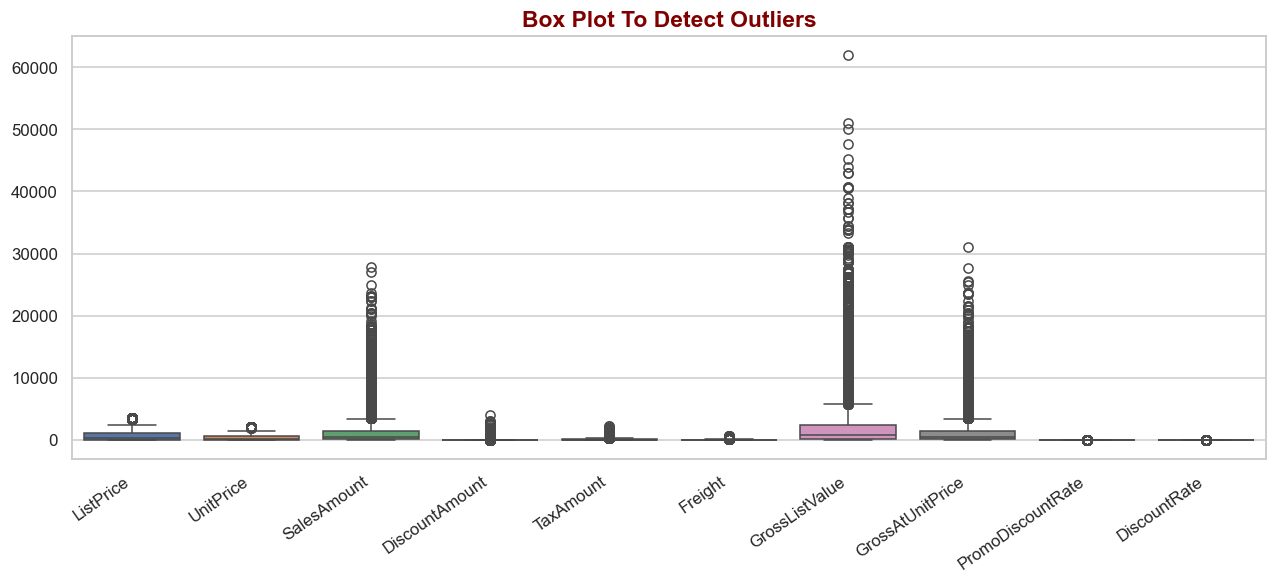

In [23]:
# I detected outliers in these numerical features
plt.figure(figsize= (14, 5) )
sns.boxplot(numerical_data)
plt.title("Box Plot To Detect Outliers", color="maroon", fontweight="bold", fontsize=15)
plt.xticks(rotation=35, ha="right")
plt.show()

In [24]:
numerical_data.skew()
# Since they are all positive, it means that they are not normalized i.e they are not normally distributed.
# This means they are skewed to the left

ListPrice             1.431559
UnitPrice             1.453984
SalesAmount           3.540029
DiscountAmount       21.316709
TaxAmount             3.540029
Freight               3.540029
GrossListValue        3.804086
GrossAtUnitPrice      3.609814
PromoDiscountRate     6.501717
DiscountRate          6.013012
dtype: float64

In [61]:
from pathlib import Path

processed_dir = next(
    (
        path for path in [
            Path("../data/processed"),
            Path("data/processed")
        ]
        if path.exists()
    ),
    Path("../data/processed")
)

processed_dir.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA_PATH = processed_dir / "retail_sales_cleaned.csv"

df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Saved cleaned data to: {PROCESSED_DATA_PATH.resolve()}")

Saved cleaned data to: C:\Users\DELL\projects\retail-sales-performance-analysis\data\processed\retail_sales_cleaned.csv


# 7. Product and Category Performance

This section evaluates product and category performance using sales and revenue metrics.


**Category Summary**

In [25]:
category_summary = (
    df.groupby("Category", as_index=False)
      .agg(
          total_sales=("SalesAmount", "sum"),
          total_units=("OrderQuantity", "sum"),
          unique_orders=("OrderNumber", "nunique"),
          average_line_sales=("SalesAmount", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

category_summary["sales_share_pct"] = (
    category_summary["total_sales"] / category_summary["total_sales"].sum() * 100
).round(2)

category_summary

,Category,total_sales,total_units,unique_orders,average_line_sales,sales_share_pct
1,Bikes,3.360718e+07,38023,1542,2746.357423,80.82
3,Components,6.675045e+06,28175,1394,639.249660,16.05
2,Clothing,9.789171e+05,35548,1188,150.117642,2.35
0,Accessories,3.227301e+05,14354,689,114.891471,0.78


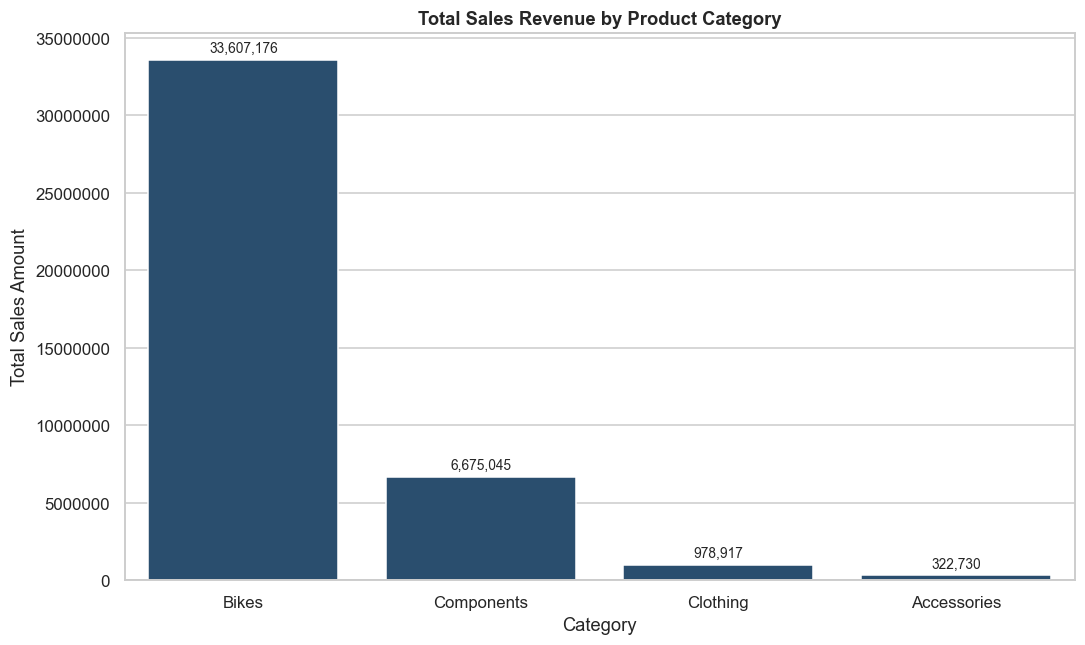

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=category_summary,
    x="Category",
    y="total_sales",
    color="#1f4e79"
)

plt.title("Total Sales Revenue by Product Category", fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales Amount")
plt.ticklabel_format(style="plain", axis="y")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:,.0f}" for value in category_summary["total_sales"]],
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_sales_by_category.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

**Top products by revenue**

In [27]:
top_products_revenue = (
    df.groupby(["ProductName", "Category"], as_index=False)
      .agg(
          total_sales=("SalesAmount", "sum"),
          units_sold=("OrderQuantity", "sum"),
          unique_orders=("OrderNumber", "nunique")
      )
      .sort_values("total_sales", ascending=False)
      .head(10)
)

top_products_revenue

,ProductName,Category,total_sales,units_sold,unique_orders
142,"Mountain-200 Black, 38",Bikes,1.635382e+06,1262,338
143,"Mountain-200 Black, 42",Bikes,1.454003e+06,1126,298
146,"Mountain-200 Silver, 42",Bikes,1.211666e+06,933,264
145,"Mountain-200 Silver, 38",Bikes,1.211252e+06,925,244
147,"Mountain-200 Silver, 46",Bikes,1.181514e+06,909,259
144,"Mountain-200 Black, 46",Bikes,1.005378e+06,774,225
176,"Road-250 Black, 44",Bikes,9.826848e+05,714,213
177,"Road-250 Black, 48",Bikes,8.366475e+05,607,204
224,"Touring-1000 Blue, 60",Bikes,7.454827e+05,530,146
187,"Road-350-W Yellow, 48",Bikes,7.030379e+05,713,165


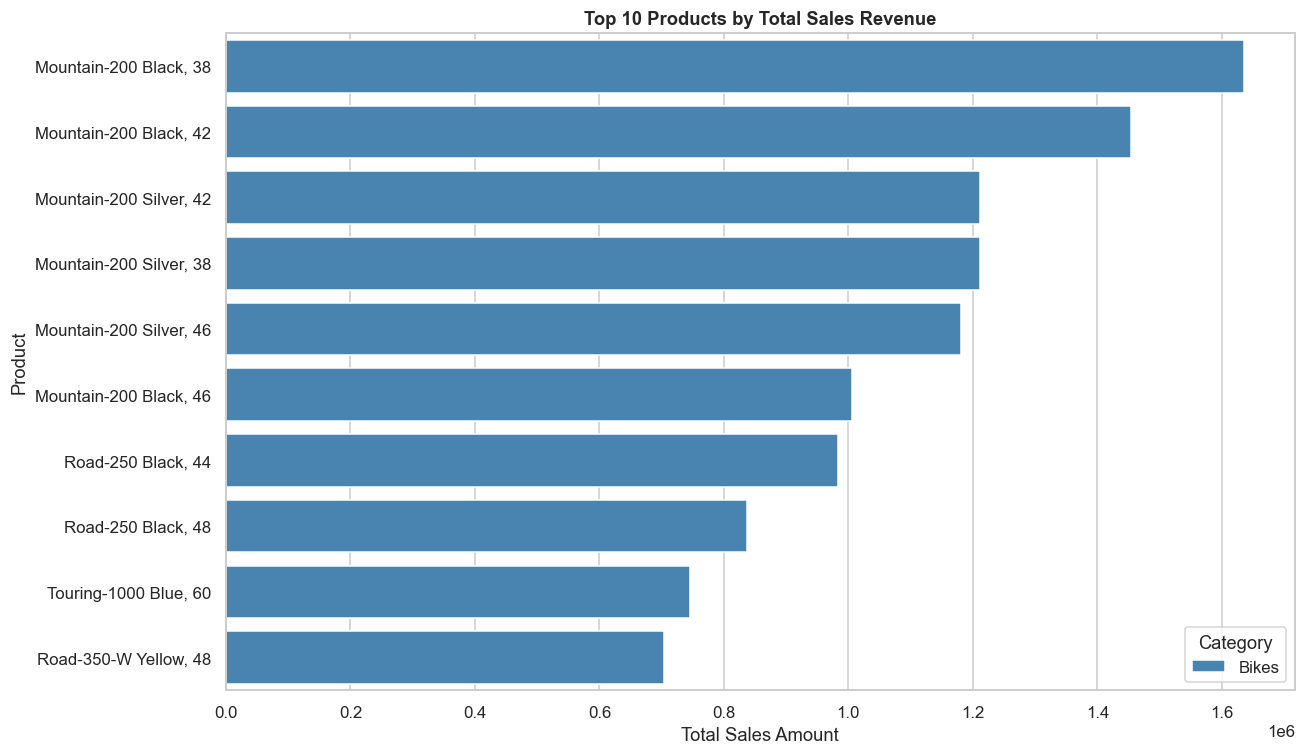

In [28]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_products_revenue,
    y="ProductName",
    x="total_sales",
    hue="Category",
    dodge=False,
    palette="Blues_d"
)

plt.title("Top 10 Products by Total Sales Revenue", fontweight="bold")
plt.xlabel("Total Sales Amount")
plt.ylabel("Product")
plt.legend(title="Category")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "02_top_products_by_revenue.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

**Top subcategory by demand**

In [29]:
subcategory_summary = (
    df.groupby("Subcategory", as_index=False)
      .agg(
          total_sales=("SalesAmount", "sum"),
          units_sold=("OrderQuantity", "sum"),
          unique_orders=("OrderNumber", "nunique")
      )
)

top_subcategories_units = (
    subcategory_summary
    .sort_values("units_sold", ascending=False)
    .head(10)
)

top_subcategories_units

,Subcategory,total_sales,units_sold,unique_orders
22,Road Bikes,1.432542e+07,19149,702
18,Mountain Bikes,1.392992e+07,12202,601
16,Jerseys,3.222293e+05,10796,749
14,Helmets,1.446813e+05,7121,567
23,Road Frames,2.264918e+06,6708,562
29,Touring Bikes,5.351833e+06,6672,239
19,Mountain Frames,2.547494e+06,6406,445
11,Gloves,1.130652e+05,6318,546
25,Shorts,1.865887e+05,4912,379
31,Vests,1.231243e+05,3405,287


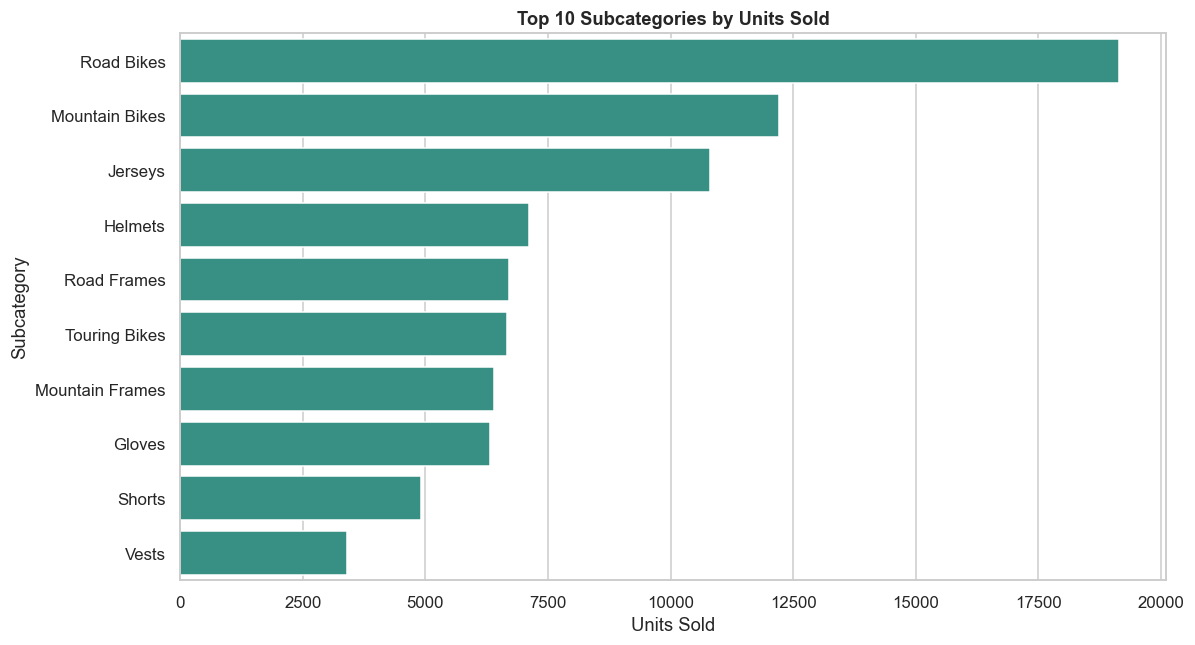

In [30]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=top_subcategories_units,
    y="Subcategory",
    x="units_sold",
    color="#2a9d8f"
)

plt.title("Top 10 Subcategories by Units Sold", fontweight="bold")
plt.xlabel("Units Sold")
plt.ylabel("Subcategory")
plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "03_top_subcategories_by_units.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

### Findings

- **Bikes** generate the largest share of revenue, followed by Components, Clothing, and Accessories.
- Revenue leadership and unit-volume leadership are different: expensive bicycle models generate the most revenue, while lower-priced clothing/accessory products can sell more units.
- At subcategory level, **Road Bikes** and **Mountain Bikes** are the largest revenue contributors.
- Product decisions should consider revenue, units, average selling value, margin, inventory cost, and stock availability together. Margin and inventory-cost data are not available here.


# 8. Regional Performance

This section examines how sales performance varies across different regions.


**Regional summary**

In [31]:
region_summary = (
    df.groupby("SalesRegion", as_index=False)
      .agg(
          total_sales=("SalesAmount", "sum"),
          units_sold=("OrderQuantity", "sum"),
          unique_orders=("OrderNumber", "nunique"),
          average_line_sales=("SalesAmount", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

region_summary["sales_share_pct"] = (
    region_summary["total_sales"] / region_summary["total_sales"].sum() * 100
).round(2)

region_summary

,SalesRegion,total_sales,units_sold,unique_orders,average_line_sales,sales_share_pct
8,Southwest,9.516476e+06,25129,368,1358.332340,22.89
1,Canada,7.284428e+06,22463,344,1204.834219,17.52
6,Northwest,6.453368e+06,15095,261,1561.802473,15.52
2,Central,4.003429e+06,10363,184,1313.891945,9.63
7,Southeast,3.949135e+06,9786,220,1308.093709,9.50
5,Northeast,3.584185e+06,10669,167,1195.525200,8.62
3,France,2.582399e+06,8208,96,1338.030634,6.21
9,United Kingdom,2.317998e+06,7316,95,1218.716086,5.57
4,Germany,1.031465e+06,4083,69,1054.667626,2.48
0,Australia,8.609859e+05,2988,62,905.347924,2.07


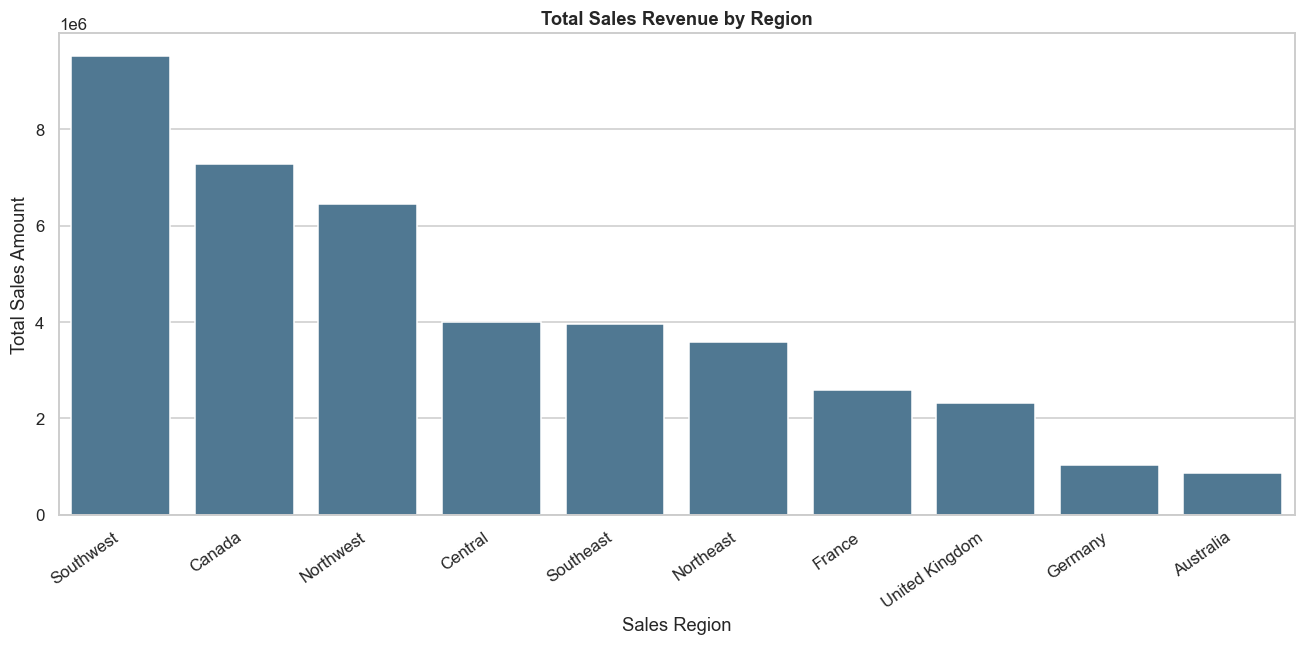

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_summary,
    x="SalesRegion",
    y="total_sales",
    color="#457b9d"
)

plt.title("Total Sales Revenue by Region", fontweight="bold")
plt.xlabel("Sales Region")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_sales_by_region.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

**Revenue vs orders**

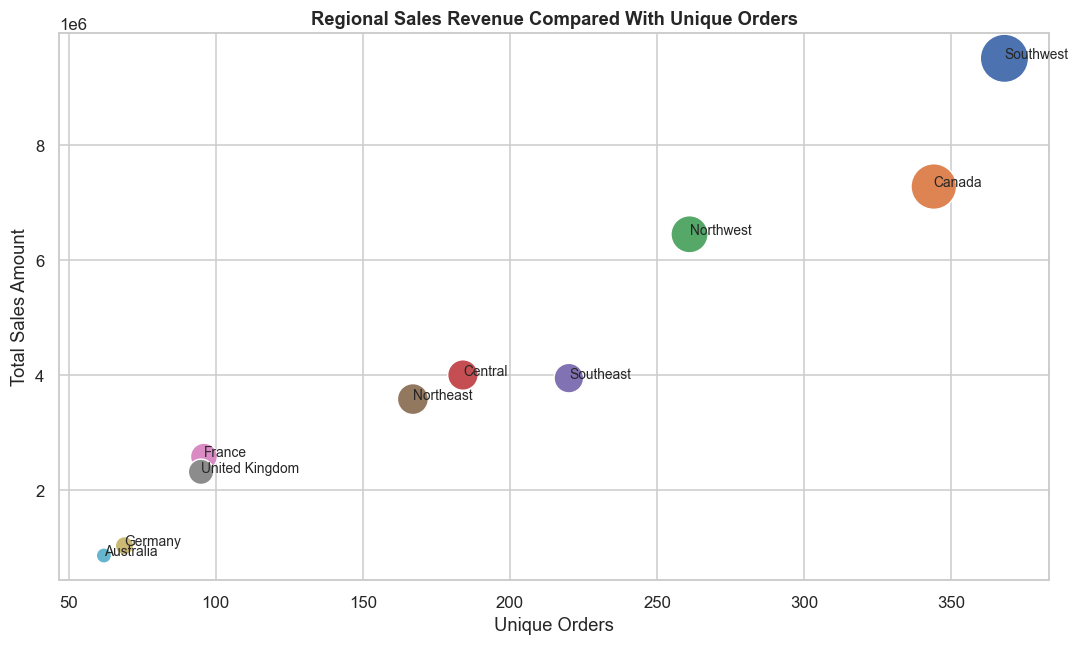

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=region_summary,
    x="unique_orders",
    y="total_sales",
    size="units_sold",
    hue="SalesRegion",
    sizes=(100, 1000),
    legend=False
)

for _, row in region_summary.iterrows():
    plt.text(
        row["unique_orders"],
        row["total_sales"],
        row["SalesRegion"],
        fontsize=9
    )

plt.title("Regional Sales Revenue Compared With Unique Orders", fontweight="bold")
plt.xlabel("Unique Orders")
plt.ylabel("Total Sales Amount")
plt.tight_layout()
plt.show()

### Findings

- **Southwest** contributes the largest share of recorded revenue, followed by Canada and Northwest.
- Regional performance should be evaluated using both revenue and unique orders; a region can have high revenue because of larger orders rather than more orders.
- A statistical test can be used to determine whether order-level revenue distributions differ across regions. Statistical significance does not explain the business reason for the difference.
- Profitability cannot be assessed because product cost, margin, and marketing-spend data are unavailable.


# 9. Promotion Analysis

This section investigates discount behavior and promotional effectiveness.



**Promotion summary**

In [34]:
promotion_summary = (
    df.groupby("PromotionName", as_index=False)
      .agg(
          total_sales=("SalesAmount", "sum"),
          units_sold=("OrderQuantity", "sum"),
          total_discount=("DiscountAmount", "sum"),
          unique_orders=("OrderNumber", "nunique"),
          average_line_sales=("SalesAmount", "mean")
      )
)

promotion_summary["discount_rate_pct"] = np.where(
    promotion_summary["total_sales"] > 0,
    promotion_summary["total_discount"] /
    (promotion_summary["total_sales"] + promotion_summary["total_discount"]) * 100,
    np.nan
).round(2)

promotion_summary = promotion_summary.sort_values(
    "total_sales", ascending=False
)

promotion_summary

,PromotionName,total_sales,units_sold,total_discount,unique_orders,average_line_sales,discount_rate_pct
0,No Discount,3.837943e+07,97328,0.0000,1858,1268.993300,0.0
4,Volume Discount 11 to 14,1.684655e+06,8898,34380.7203,314,2326.871982,2.0
5,Volume Discount 15 to 24,6.112321e+05,6493,32170.1142,200,1670.033043,5.0
2,Touring-1000 Promotion,4.478237e+05,587,111955.9272,78,2433.824504,20.0
3,Touring-3000 Promotion,3.472695e+05,1223,61282.8524,81,857.455513,15.0
6,Volume Discount 25 to 40,8.566576e+04,1402,9518.4176,41,1748.280784,10.0
1,Road-650 Overstock,2.778832e+04,169,11909.2779,37,751.035543,30.0


**Promotion chart: sales revenue**

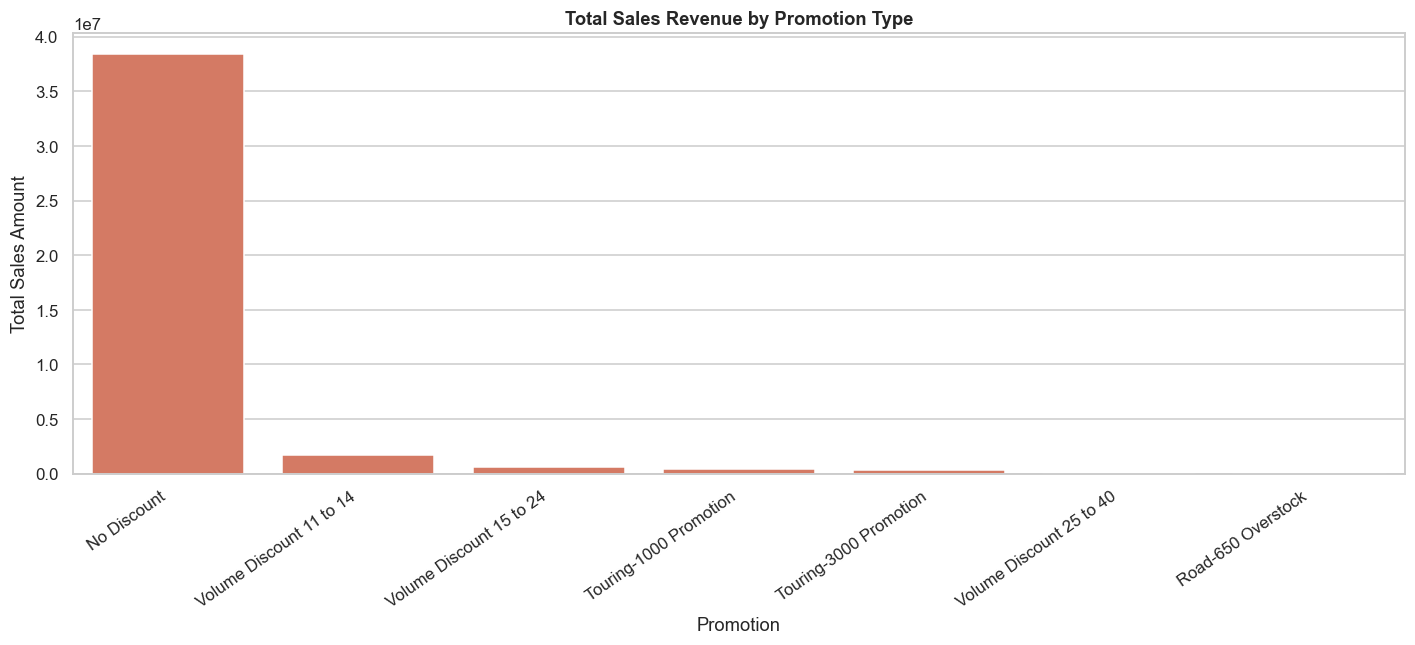

In [35]:
promotion_plot = promotion_summary.copy()

plt.figure(figsize=(13, 6))
sns.barplot(
    data=promotion_plot,
    x="PromotionName",
    y="total_sales",
    color="#e76f51"
)

plt.title("Total Sales Revenue by Promotion Type", fontweight="bold")
plt.xlabel("Promotion")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Promotion chart: total discounts**

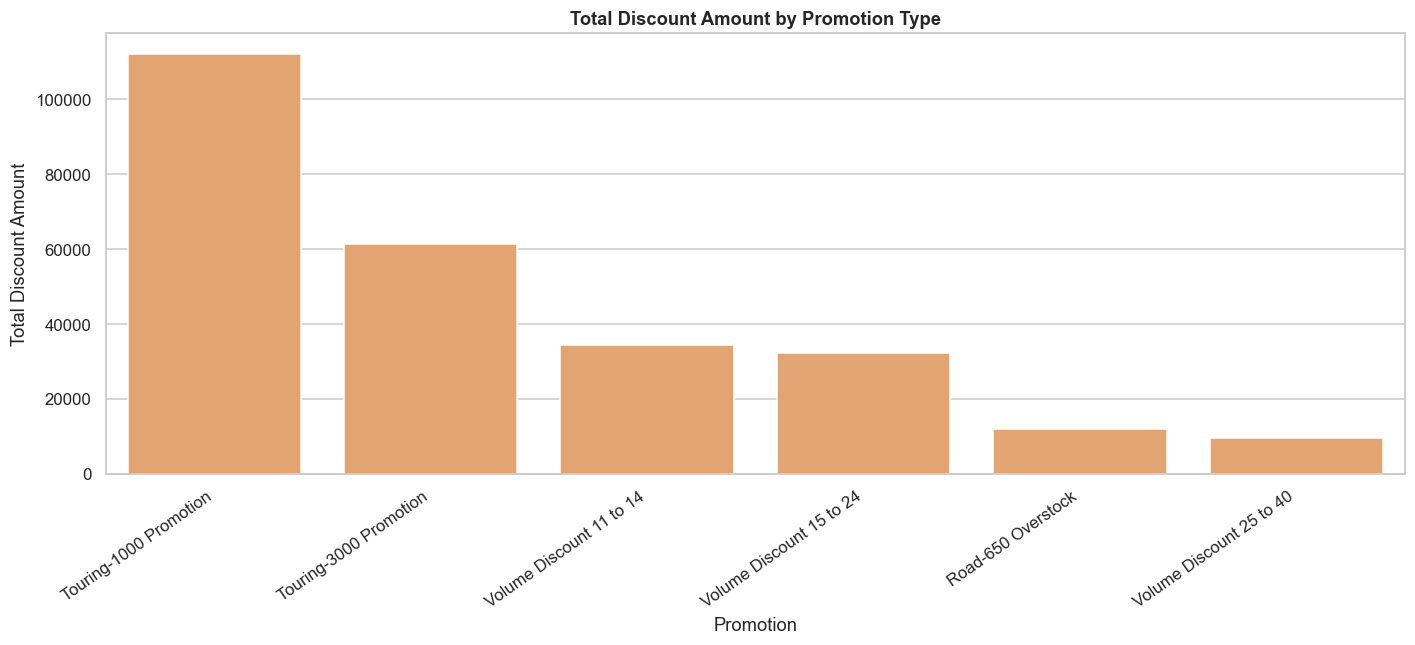

In [36]:
discounted_promotions = promotion_summary[
    promotion_summary["PromotionName"] != "No Discount"
].sort_values("total_discount", ascending=False)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=discounted_promotions,
    x="PromotionName",
    y="total_discount",
    color="#f4a261"
)

plt.title("Total Discount Amount by Promotion Type", fontweight="bold")
plt.xlabel("Promotion")
plt.ylabel("Total Discount Amount")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "05_promotion_performance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

### Findings

- Most transaction lines have **No Discount**, so total revenue for that promotion type is naturally much larger.
- Among discounted promotion types, **Volume Discount 11-14** records the highest total revenue.
- The largest total promotional discount amounts are concentrated in specific products/promotions, particularly Touring-1000 products.
- Discount/revenue relationships are descriptive and do **not** prove that discounts caused higher sales. Product mix and promotion targeting can confound the relationship.
- Promotion profitability cannot be determined without product cost or gross-margin data.


# 10. Time-Series Analysis

This section analyzes sales trends over time.



**Monthly sales Trend**

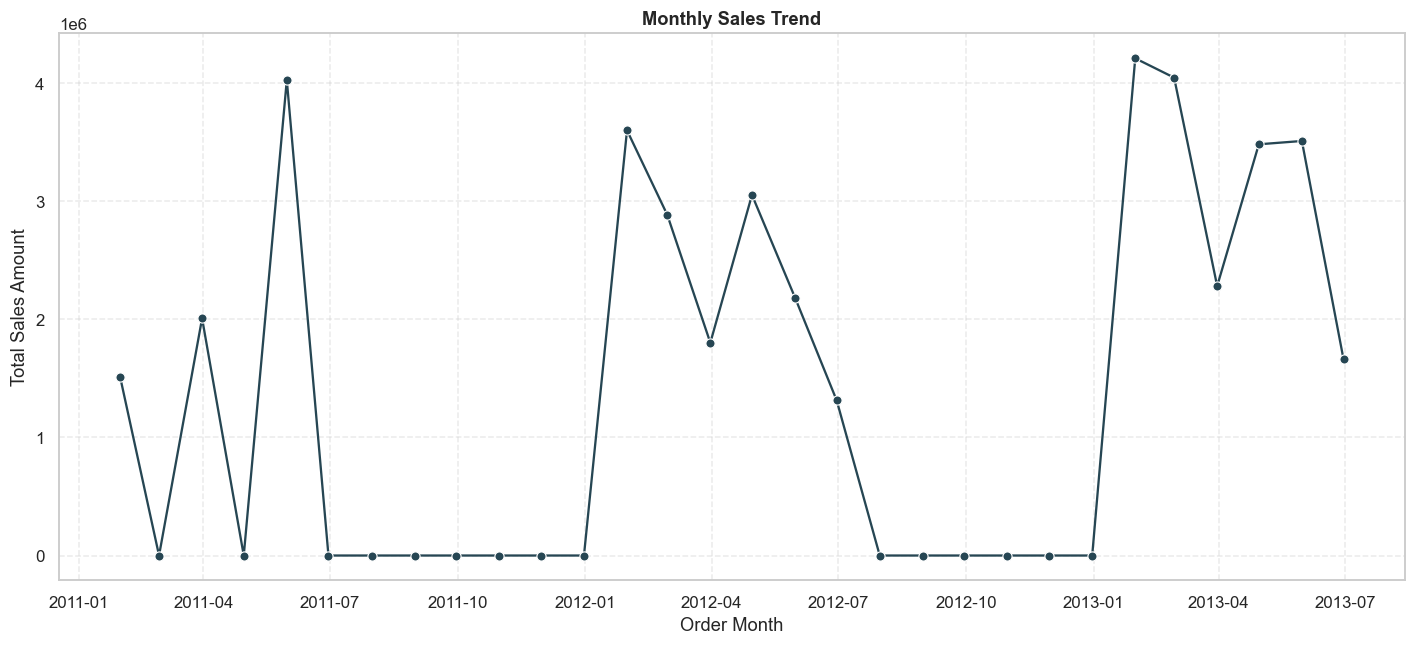

In [37]:
monthly_sales = (
    df.groupby(pd.Grouper(key="OrderDate", freq="ME"))["SalesAmount"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=monthly_sales,
    x="OrderDate",
    y="SalesAmount",
    marker="o",
    color="#264653"
)

plt.title("Monthly Sales Trend", fontweight="bold")
plt.xlabel("Order Month")
plt.ylabel("Total Sales Amount")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "06_monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

**Months without Sales**

In [38]:
full_month_index = pd.date_range(
    start=df["OrderDate"].min().to_period("M").to_timestamp(),
    end=df["OrderDate"].max().to_period("M").to_timestamp(),
    freq="MS"
)

monthly_sales_complete = (
    monthly_sales
    .set_index("OrderDate")
    .reindex(full_month_index)
    .rename_axis("OrderDate")
    .reset_index()
)

missing_or_zero_months = monthly_sales_complete[
    monthly_sales_complete["SalesAmount"].isna() |
    monthly_sales_complete["SalesAmount"].eq(0)
]

missing_or_zero_months

,OrderDate,SalesAmount
0,2011-01-01,NaN
1,2011-02-01,NaN
2,2011-03-01,NaN
3,2011-04-01,NaN
4,2011-05-01,NaN
5,2011-06-01,NaN
6,2011-07-01,NaN
7,2011-08-01,NaN
8,2011-09-01,NaN
9,2011-10-01,NaN


The monthly trend should be interpreted with caution because the dataset does not appear to contain continuous activity for every calendar month. Months with zero or missing recorded sales may reflect incomplete source coverage rather than true zero demand.

For this reason, the analysis reports observed sales patterns but does not make a strong claim about seasonality or post-festive demand without complete multi-year monthly data.


**Yearly sales**

In [39]:
yearly_sales = (
    df.groupby("OrderYear", as_index=False)
      .agg(
          total_sales=("SalesAmount", "sum"),
          unique_orders=("OrderNumber", "nunique"),
          units_sold=("OrderQuantity", "sum")
      )
)

yearly_sales

,OrderYear,total_sales,unique_orders,units_sold
0,2011,7.546659e+06,327,9993
1,2012,1.484059e+07,632,42946
2,2013,1.919662e+07,907,63161


### Findings

- Recorded annual sales totals increase across the available periods, but **2013 contains only January-June**, so it is not comparable with the full-year totals for 2011 and 2012.
- Monthly sales show variation across the observed period, with relatively high recorded revenue in some months such as January and May.
- Because the dataset contains only part of 2013 and a relatively short time history, seasonal conclusions should be treated as indicative rather than definitive.
- The data does not support attributing sales growth specifically to discounts, marketing, or a post-festive effect without additional causal evidence.


# 11. Operational Shipping Analysis

This section evaluates operational efficiency related to shipping and fulfillment.


**Operational summary**

In [40]:
shipping_summary = pd.DataFrame({
    "Metric": [
        "Average order-to-ship time (days)",
        "Median order-to-ship time (days)",
        "Average planned fulfilment window (days)",
        "Average ship-versus-due timing (days)",
        "Share shipped before due date (%)",
        "Share shipped on due date (%)",
        "Share shipped after due date (%)"
    ],
    "Value": [
        df["OrderToShipDays"].mean(),
        df["OrderToShipDays"].median(),
        df["OrderToDueDays"].mean(),
        df["ShipVsDueDays"].mean(),
        (df["ShipmentStatus"].eq("Shipped Before Due Date").mean() * 100),
        (df["ShipmentStatus"].eq("Shipped On Due Date").mean() * 100),
        (df["ShipmentStatus"].eq("Shipped After Due Date").mean() * 100)
    ]
})

shipping_summary["Value"] = shipping_summary["Value"].round(2)
shipping_summary

,Metric,Value
0,Average order-to-ship time (days),7.0
1,Median order-to-ship time (days),7.0
2,Average planned fulfilment window (days),12.0
3,Average ship-versus-due timing (days),-5.0
4,Share shipped before due date (%),100.0
5,Share shipped on due date (%),0.0
6,Share shipped after due date (%),0.0


**Shipping status chart**

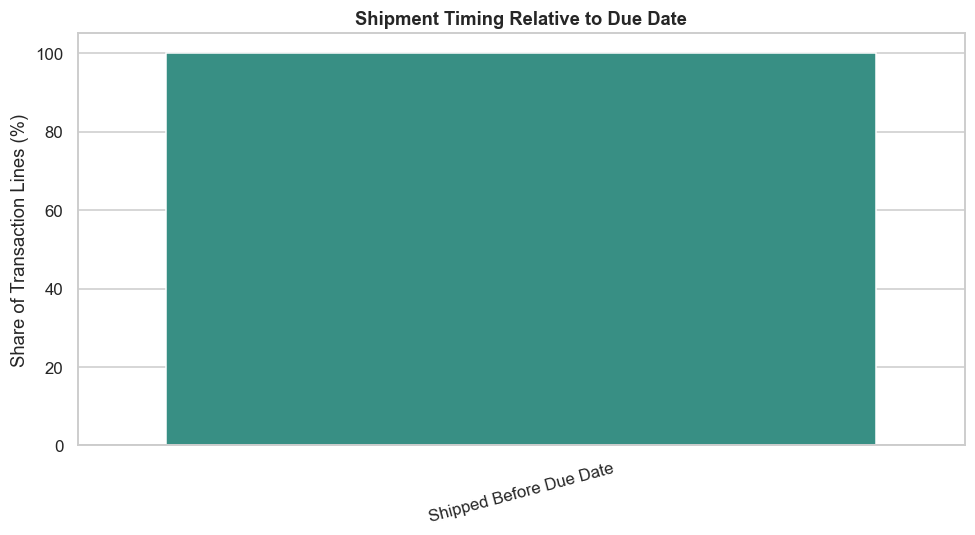

In [41]:
shipment_status_summary = (
    df["ShipmentStatus"]
      .value_counts()
      .rename_axis("ShipmentStatus")
      .reset_index(name="transaction_lines")
)

shipment_status_summary["share_pct"] = (
    shipment_status_summary["transaction_lines"] /
    shipment_status_summary["transaction_lines"].sum() * 100
).round(2)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=shipment_status_summary,
    x="ShipmentStatus",
    y="share_pct",
    color="#2a9d8f"
)

plt.title("Shipment Timing Relative to Due Date", fontweight="bold")
plt.xlabel("")
plt.ylabel("Share of Transaction Lines (%)")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "07_shipment_timing.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

**Order-to-ship time by region**

In [42]:
regional_shipping = (
    df.groupby("SalesRegion", as_index=False)
      .agg(
          avg_order_to_ship_days=("OrderToShipDays", "mean"),
          median_order_to_ship_days=("OrderToShipDays", "median"),
          avg_ship_vs_due_days=("ShipVsDueDays", "mean")
      )
      .sort_values("avg_order_to_ship_days", ascending=False)
)

regional_shipping

,SalesRegion,avg_order_to_ship_days,median_order_to_ship_days,avg_ship_vs_due_days
0,Australia,7.0,7.0,-5.0
1,Canada,7.0,7.0,-5.0
2,Central,7.0,7.0,-5.0
3,France,7.0,7.0,-5.0
4,Germany,7.0,7.0,-5.0
5,Northeast,7.0,7.0,-5.0
6,Northwest,7.0,7.0,-5.0
7,Southeast,7.0,7.0,-5.0
8,Southwest,7.0,7.0,-5.0
9,United Kingdom,7.0,7.0,-5.0


### Findings

- The average and median order-to-ship time are both **7 days**.
- The average order-to-due window is **12 days**.
- Shipment occurs, on average, **5 days before the recorded due date**.
- The dataset records **no transaction lines shipped after the due date**.
- This measures shipment timing, not final customer delivery, because an actual delivery date is not present.


# 12. Extended Business Analysis

This section extends the original questions with additional KPIs and statistical tests. It distinguishes revenue, sales volume, order activity, discount association, and operational timing.

In [43]:
# Core KPIs
total_revenue = df["SalesAmount"].sum()
total_units = df["OrderQuantity"].sum()
unique_orders = df["OrderNumber"].nunique()

order_summary = (
    df.groupby("OrderNumber")
      .agg(
          order_revenue=("SalesAmount", "sum"),
          order_units=("OrderQuantity", "sum"),
          product_lines=("ProductName", "count"),
          discount=("DiscountAmount", "sum")
      )
)

core_kpis = pd.DataFrame({
    "Metric": [
        "Total revenue",
        "Total units sold",
        "Unique orders",
        "Average order value",
        "Median order value",
        "Average units per order",
        "Average product lines per order"
    ],
    "Value": [
        total_revenue,
        total_units,
        unique_orders,
        order_summary["order_revenue"].mean(),
        order_summary["order_revenue"].median(),
        order_summary["order_units"].mean(),
        order_summary["product_lines"].mean()
    ]
})
core_kpis["Value"] = core_kpis["Value"].round(2)
core_kpis

,Metric,Value
0,Total revenue,41583868.02
1,Total units sold,116100.00
2,Unique orders,1866.00
3,Average order value,22285.03
4,Median order value,8764.45
5,Average units per order,62.22
6,Average product lines per order,17.15


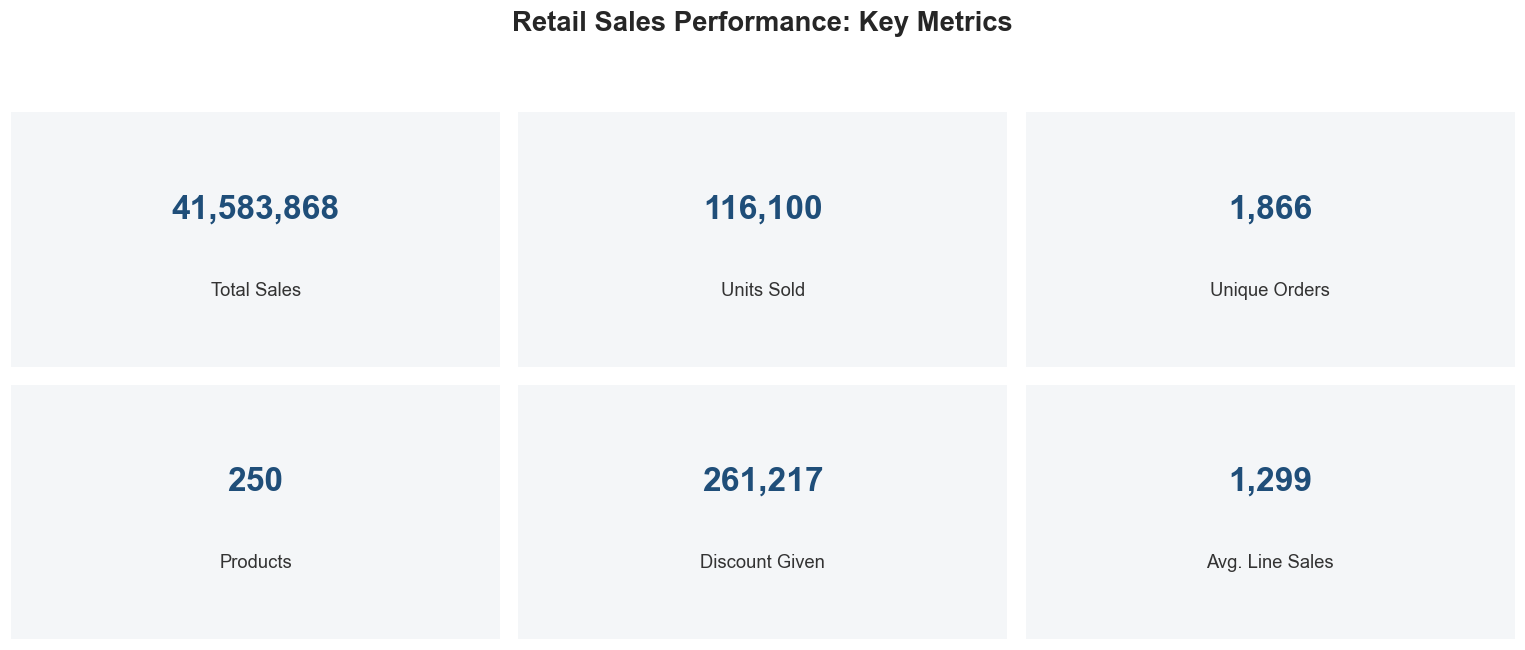

In [44]:
total_sales = df["SalesAmount"].sum()
total_units = df["OrderQuantity"].sum()
unique_orders = df["OrderNumber"].nunique()
unique_products = df["ProductName"].nunique()
total_discount = df["DiscountAmount"].sum()
average_line_sales = df["SalesAmount"].mean()

kpis = [
    ("Total Sales", f"{total_sales:,.0f}"),
    ("Units Sold", f"{total_units:,.0f}"),
    ("Unique Orders", f"{unique_orders:,}"),
    ("Products", f"{unique_products:,}"),
    ("Discount Given", f"{total_discount:,.0f}"),
    ("Avg. Line Sales", f"{average_line_sales:,.0f}")
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle("Retail Sales Performance: Key Metrics", fontsize=18, fontweight="bold")

for ax, (label, value) in zip(axes.flatten(), kpis):
    ax.set_facecolor("#f4f6f8")
    ax.text(
        0.5, 0.62, value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color="#1f4e79"
    )
    ax.text(
        0.5, 0.30, label,
        ha="center",
        va="center",
        fontsize=12,
        color="#333333"
    )
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(
    FIGURES_DIR / "08_kpi_overview.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

**KPI Overview**

The dataset is transaction-line level, not order level. Therefore:

- Sales and units are aggregated across product lines.
- `OrderNumber.nunique()` is used when the analysis refers to unique orders.
- A line with a high sales amount is not necessarily an entire customer order.

### 12.1 Product Portfolio: Revenue vs Volume

A product can sell many units without generating the most revenue, while a high-priced product can generate substantial revenue with fewer units. This two-dimensional view prevents revenue-only or volume-only conclusions.

In [45]:
product_performance = (
    df.groupby(["ProductName", "Category"], as_index=False)
      .agg(
          Revenue=("SalesAmount", "sum"),
          Units=("OrderQuantity", "sum"),
          Orders=("OrderNumber", "nunique"),
          DiscountValue=("DiscountAmount", "sum")
      )
)

product_performance["RevenuePerUnit"] = (
    product_performance["Revenue"] / product_performance["Units"]
)

top_volume = product_performance.sort_values("Units", ascending=False).head(10)
top_revenue = product_performance.sort_values("Revenue", ascending=False).head(10)

print("Top 10 products by revenue")
display(top_revenue)

print("Top 10 products by units sold")
display(top_volume)

Top 10 products by revenue


,ProductName,Category,Revenue,Units,Orders,DiscountValue,RevenuePerUnit
142,"Mountain-200 Black, 38",Bikes,1.635382e+06,1262,338,3936.3669,1295.864922
143,"Mountain-200 Black, 42",Bikes,1.454003e+06,1126,298,2430.8616,1291.299627
146,"Mountain-200 Silver, 42",Bikes,1.211666e+06,933,264,1137.0270,1298.677304
145,"Mountain-200 Silver, 38",Bikes,1.211252e+06,925,244,1252.3637,1309.461949
147,"Mountain-200 Silver, 46",Bikes,1.181514e+06,909,259,872.7139,1299.794842
144,"Mountain-200 Black, 46",Bikes,1.005378e+06,774,225,839.5401,1298.937345
176,"Road-250 Black, 44",Bikes,9.826848e+05,714,213,1138.7757,1376.309286
177,"Road-250 Black, 48",Bikes,8.366475e+05,607,204,278.3674,1378.332034
224,"Touring-1000 Blue, 60",Bikes,7.454827e+05,530,146,4569.5471,1406.571162
187,"Road-350-W Yellow, 48",Bikes,7.030379e+05,713,165,8656.3381,986.027879


Top 10 products by units sold


,ProductName,Category,Revenue,Units,Orders,DiscountValue,RevenuePerUnit
97,"Long-Sleeve Logo Jersey, L",Clothing,96955.3372,3394,622,996.5400,28.566687
0,AWC Logo Cap,Clothing,17299.1604,3361,622,167.3125,5.147028
218,"Sport-100 Helmet, Blue",Accessories,50256.7612,2478,515,267.9412,20.281179
217,"Sport-100 Helmet, Black",Accessories,48970.7214,2410,506,234.2141,20.319801
219,"Sport-100 Helmet, Red",Accessories,45453.8053,2233,474,188.0485,20.355488
6,"Classic Vest, S",Clothing,78445.9196,2204,269,1929.8420,35.592523
216,"Short-Sleeve Classic Jersey, XL",Clothing,59468.4897,1918,270,952.2596,31.005469
98,"Long-Sleeve Logo Jersey, M",Clothing,52029.3749,1785,415,169.8848,29.148109
9,"Full-Finger Gloves, L",Clothing,36456.1958,1753,183,1205.9510,20.796461
50,"Half-Finger Gloves, M",Clothing,24031.0470,1684,330,154.0789,14.270218


In [46]:
# Revenue-per-unit view
top_revenue_per_unit = (
    product_performance[product_performance["Units"] >= 100]
    .sort_values("RevenuePerUnit", ascending=False)
    .head(10)
)

top_revenue_per_unit

,ProductName,Category,Revenue,Units,Orders,DiscountValue,RevenuePerUnit
175,"Road-150 Red, 62",Bikes,227577.9720,106,53,0.0000,2146.962000
174,"Road-150 Red, 56",Bikes,349954.8060,163,76,0.0000,2146.962000
141,"Mountain-100 Silver, 48",Bikes,444718.6920,218,74,0.0000,2039.994000
138,"Mountain-100 Silver, 38",Bikes,567118.3320,278,84,0.0000,2039.994000
139,"Mountain-100 Silver, 42",Bikes,524814.2964,258,83,552.1584,2034.163940
140,"Mountain-100 Silver, 44",Bikes,515579.9236,254,76,946.5572,2029.842219
137,"Mountain-100 Black, 48",Bikes,510298.4880,252,82,0.0000,2024.994000
135,"Mountain-100 Black, 42",Bikes,561668.5358,278,79,469.7986,2020.390417
136,"Mountain-100 Black, 44",Bikes,582770.3233,289,79,900.4473,2016.506309
134,"Mountain-100 Black, 38",Bikes,576588.6916,286,76,939.5972,2016.044376


### 12.2 Regional Performance Significance

A Kruskal-Wallis test compares the distribution of order-level revenue across regions. Order-level aggregation avoids treating every product line within an order as an independent order observation.

In [47]:
order_region = (
    df.groupby(["OrderNumber", "SalesRegion"], dropna=False)
      .agg(
          Revenue=("SalesAmount", "sum"),
          Units=("OrderQuantity", "sum")
      )
      .reset_index()
)

region_groups = [
    group["Revenue"].dropna().values
    for region_name, group in order_region.groupby("SalesRegion")
    if pd.notna(region_name)
]

kw_stat, kw_p = kruskal(*region_groups)

regional_test = pd.DataFrame({
    "Test": ["Kruskal-Wallis: order revenue across regions"],
    "Statistic": [kw_stat],
    "p_value": [kw_p]
})

regional_test

,Test,Statistic,p_value
0,Kruskal-Wallis: order revenue across regions,29.197771,0.0006


**Interpretation:** a p-value below 0.05 indicates evidence that at least one region has a different order-revenue distribution. This is not a ranking of regional quality and does not identify the cause of the difference.

### 12.3 Promotion Effect Analysis

The dataset contains promotional discounts, but observational data cannot by itself prove that a discount caused a change in sales. The analysis therefore reports promotion-level performance and association statistics.

In [48]:
promotion_order = (
    df.groupby(["OrderNumber", "PromotionName"])
      .agg(
          Revenue=("SalesAmount", "sum"),
          Units=("OrderQuantity", "sum"),
          Discount=("DiscountAmount", "sum")
      )
      .reset_index()
)

promotion_order["DiscountRate"] = np.where(
    (promotion_order["Revenue"] + promotion_order["Discount"]) > 0,
    promotion_order["Discount"] /
    (promotion_order["Revenue"] + promotion_order["Discount"]),
    np.nan
)

promotion_comparison = (
    promotion_order.groupby("PromotionName")
    .agg(
        Orders=("OrderNumber", "nunique"),
        AvgOrderRevenue=("Revenue", "mean"),
        MedianOrderRevenue=("Revenue", "median"),
        AvgUnits=("Units", "mean"),
        TotalDiscount=("Discount", "sum"),
        AvgDiscountRate=("DiscountRate", "mean")
    )
    .sort_values("AvgOrderRevenue", ascending=False)
)

promotion_comparison.round(3)

,Orders,AvgOrderRevenue,MedianOrderRevenue,AvgUnits,TotalDiscount,AvgDiscountRate
PromotionName,,,,,,
No Discount,1858,20656.315,8771.071,52.383,0.000,0.00
Touring-1000 Promotion,78,5741.330,3814.512,7.526,111955.927,0.20
Volume Discount 11 to 14,314,5365.144,814.975,28.338,34380.720,0.02
Touring-3000 Promotion,81,4287.278,3691.335,15.099,61282.852,0.15
Volume Discount 15 to 24,200,3056.160,661.313,32.465,32170.114,0.05
Volume Discount 25 to 40,41,2089.409,787.388,34.195,9518.418,0.10
Road-650 Overstock,37,751.036,493.284,4.568,11909.278,0.30


In [49]:
rho_sales, p_sales = spearmanr(
    df["PromoDiscountRate"], df["SalesAmount"], nan_policy="omit"
)
rho_units, p_units = spearmanr(
    df["PromoDiscountRate"], df["OrderQuantity"], nan_policy="omit"
)

discount_association = pd.DataFrame({
    "Relationship": [
        "Promotional discount rate vs SalesAmount",
        "Promotional discount rate vs OrderQuantity"
    ],
    "Spearman_rho": [rho_sales, rho_units],
    "p_value": [p_sales, p_units]
})

discount_association.round(4)

,Relationship,Spearman_rho,p_value
0,Promotional discount rate vs SalesAmount,0.0482,0.0
1,Promotional discount rate vs OrderQuantity,0.2390,0.0


### 12.4 Product Discount Concentration

In [50]:
product_discounts = (
    df.groupby("ProductName", as_index=False)
      .agg(
          TotalDiscount=("DiscountAmount", "sum"),
          Revenue=("SalesAmount", "sum"),
          Units=("OrderQuantity", "sum")
      )
      .sort_values("TotalDiscount", ascending=False)
      .head(10)
)

product_discounts

,ProductName,TotalDiscount,Revenue,Units
228,"Touring-1000 Yellow, 60",49096.3455,588523.1760,530
225,"Touring-1000 Yellow, 46",34378.2894,474859.0626,415
226,"Touring-1000 Yellow, 50",21170.5416,292096.2564,256
227,"Touring-1000 Yellow, 54",13541.5176,137131.7064,129
204,"Road-650 Red, 44",13334.6330,422979.8245,1051
242,"Touring-3000 Yellow, 62",9523.7572,159108.4705,426
234,"Touring-3000 Blue, 50",9181.0887,156348.1164,417
238,"Touring-3000 Yellow, 44",8963.9510,156453.9010,416
187,"Road-350-W Yellow, 48",8656.3381,703037.8779,713
235,"Touring-3000 Blue, 54",8167.7065,128684.5173,348


### 12.5 Seasonality Check

The dataset ends in June 2013, so July-December 2013 are not observed. Calendar-month totals are therefore descriptive and should not be treated as a complete seasonal forecast.

In [51]:
seasonality = (
    df.groupby("OrderMonth", as_index=False)
      .agg(
          Revenue=("SalesAmount", "sum"),
          Units=("OrderQuantity", "sum"),
          Orders=("OrderNumber", "nunique")
      )
)

calendar_month = (
    df.groupby("OrderMonthName", as_index=False)
      .agg(
          Revenue=("SalesAmount", "sum"),
          Units=("OrderQuantity", "sum"),
          Orders=("OrderNumber", "nunique")
      )
)

# Sort calendar months in normal order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
calendar_month["OrderMonthName"] = pd.Categorical(
    calendar_month["OrderMonthName"],
    categories=month_order,
    ordered=True
)
calendar_month = calendar_month.sort_values("OrderMonthName")

calendar_month

,OrderMonthName,Revenue,Units,Orders
2,January,9.323220e+06,28213,397
1,February,6.932933e+06,23642,287
4,March,6.092863e+06,15565,272
0,April,6.536654e+06,18658,311
5,May,9.722417e+06,22121,443
3,June,2.975781e+06,7901,156


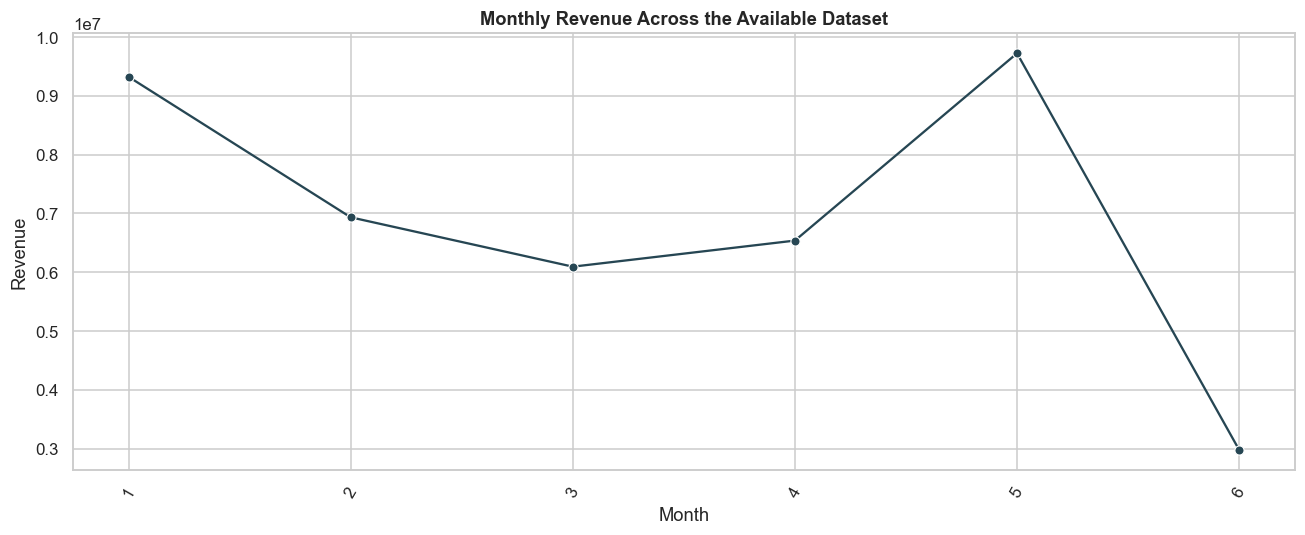

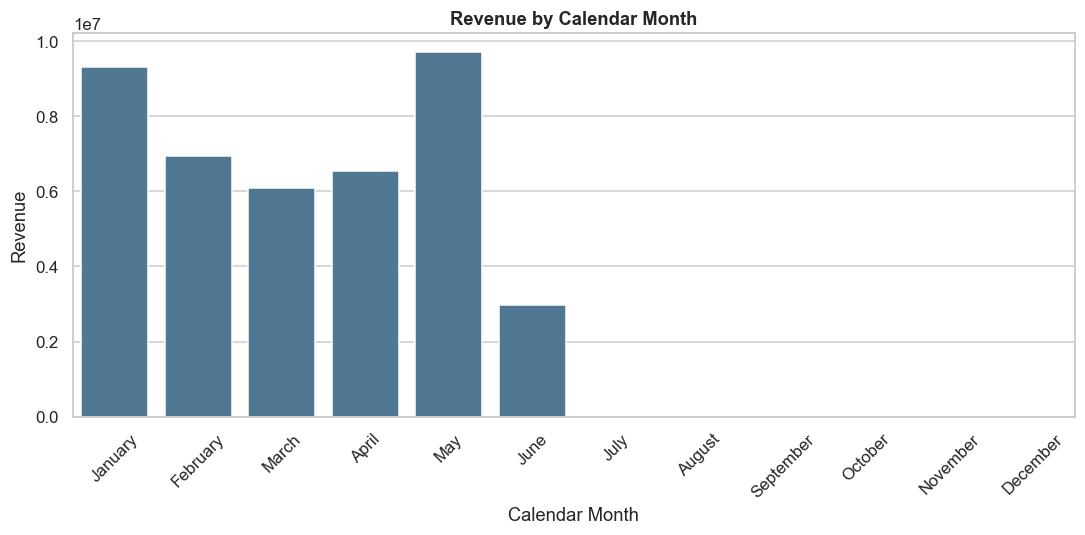

In [52]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=seasonality,
    x="OrderMonth",
    y="Revenue",
    marker="o",
    color="#264653"
)
plt.title("Monthly Revenue Across the Available Dataset")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=calendar_month,
    x="OrderMonthName",
    y="Revenue",
    color="#457b9d"
)
plt.title("Revenue by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 12.6 Operational Delay Analysis

In [53]:
operational_summary = pd.DataFrame({
    "Metric": [
        "Average order-to-ship days",
        "Median order-to-ship days",
        "Average order-to-due days",
        "Average ship-vs-due days",
        "Minimum ship-vs-due days",
        "Maximum ship-vs-due days",
        "Late shipment rate (%)"
    ],
    "Value": [
        df["OrderToShipDays"].mean(),
        df["OrderToShipDays"].median(),
        df["OrderToDueDays"].mean(),
        df["ShipVsDueDays"].mean(),
        df["ShipVsDueDays"].min(),
        df["ShipVsDueDays"].max(),
        (df["ShipmentStatus"] == "Shipped After Due Date").mean() * 100
    ]
})

operational_summary["Value"] = operational_summary["Value"].round(2)
operational_summary

,Metric,Value
0,Average order-to-ship days,7.0
1,Median order-to-ship days,7.0
2,Average order-to-due days,12.0
3,Average ship-vs-due days,-5.0
4,Minimum ship-vs-due days,-5.0
5,Maximum ship-vs-due days,-5.0
6,Late shipment rate (%),0.0


In [54]:
# Regional operational comparison
regional_operations = (
    df.groupby("SalesRegion", as_index=False)
      .agg(
          avg_order_to_ship=("OrderToShipDays", "mean"),
          median_order_to_ship=("OrderToShipDays", "median"),
          avg_ship_vs_due=("ShipVsDueDays", "mean"),
          late_rate=("ShipmentStatus",
                     lambda s: (s == "Shipped After Due Date").mean() * 100)
      )
      .sort_values("avg_order_to_ship", ascending=False)
)

regional_operations.round(2)

,SalesRegion,avg_order_to_ship,median_order_to_ship,avg_ship_vs_due,late_rate
0,Australia,7.0,7.0,-5.0,0.0
1,Canada,7.0,7.0,-5.0,0.0
2,Central,7.0,7.0,-5.0,0.0
3,France,7.0,7.0,-5.0,0.0
4,Germany,7.0,7.0,-5.0,0.0
5,Northeast,7.0,7.0,-5.0,0.0
6,Northwest,7.0,7.0,-5.0,0.0
7,Southeast,7.0,7.0,-5.0,0.0
8,Southwest,7.0,7.0,-5.0,0.0
9,United Kingdom,7.0,7.0,-5.0,0.0


### 12.7 Data Quality Checks for the Final Analysis

In [55]:
final_quality = pd.DataFrame({
    "Metric": [
        "Rows after cleaning",
        "Columns",
        "Duplicate rows",
        "Missing quantity",
        "Missing order dates",
        "Missing due dates",
        "Missing ship dates",
        "Missing sales regions",
        "Negative sales amounts"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df["OrderQuantity"].isna().sum(),
        df["OrderDate"].isna().sum(),
        df["DueDate"].isna().sum(),
        df["ShipDate"].isna().sum(),
        df["SalesRegion"].isna().sum(),
        (df["SalesAmount"] < 0).sum()
    ]
})

final_quality

,Metric,Value
0,Rows after cleaning,32009
1,Columns,29
2,Duplicate rows,0
3,Missing quantity,0
4,Missing order dates,0
5,Missing due dates,0
6,Missing ship dates,0
7,Missing sales regions,0
8,Negative sales amounts,0


### 12.8 Additional Questions Answered

This extended section also answers:

1. What is the average and median order value?
2. How many units are sold per order?
3. Which products are high-volume versus high-revenue?
4. Which subcategories contribute the most revenue?
5. Which products receive the largest total promotional discounts?
6. Do order-level revenues differ significantly across regions?
7. Is there evidence of an association between promotional discount rate and sales/quantity?
8. What is the regional fulfilment performance?
9. What data is still needed to assess profitability and true promotion effectiveness?

These additions make the analysis more useful for business decision-making without claiming information that the dataset cannot support.

## 13. Correlation Analysis

Correlation analysis is performed to identify relationships between numerical variables.


In [56]:
df_correlation_check_all = df [ numerical_features ].corr()
df_correlation_check_all

,ListPrice,UnitPrice,SalesAmount,DiscountAmount,TaxAmount,Freight,GrossListValue,GrossAtUnitPrice,PromoDiscountRate,DiscountRate
ListPrice,1.000000,0.997094,0.725449,0.116450,0.725449,0.725449,0.716666,0.723302,0.061536,0.053874
UnitPrice,0.997094,1.000000,0.726606,0.065271,0.726606,0.726606,0.711522,0.722602,-0.001366,-0.007339
SalesAmount,0.725449,0.726606,1.000000,0.225332,1.000000,1.000000,0.993124,0.999381,0.020015,0.022004
DiscountAmount,0.116450,0.065271,0.225332,1.000000,0.225332,0.225331,0.337305,0.259464,0.578713,0.571237
TaxAmount,0.725449,0.726606,1.000000,0.225332,1.000000,1.000000,0.993124,0.999381,0.020015,0.022004
Freight,0.725449,0.726606,1.000000,0.225331,1.000000,1.000000,0.993124,0.999381,0.020015,0.022004
GrossListValue,0.716666,0.711522,0.993124,0.337305,0.993124,0.993124,1.000000,0.996608,0.089791,0.090212
GrossAtUnitPrice,0.723302,0.722602,0.999381,0.259464,0.999381,0.999381,0.996608,1.000000,0.040735,0.042436
PromoDiscountRate,0.061536,-0.001366,0.020015,0.578713,0.020015,0.020015,0.089791,0.040735,1.000000,0.995162
DiscountRate,0.053874,-0.007339,0.022004,0.571237,0.022004,0.022004,0.090212,0.042436,0.995162,1.000000


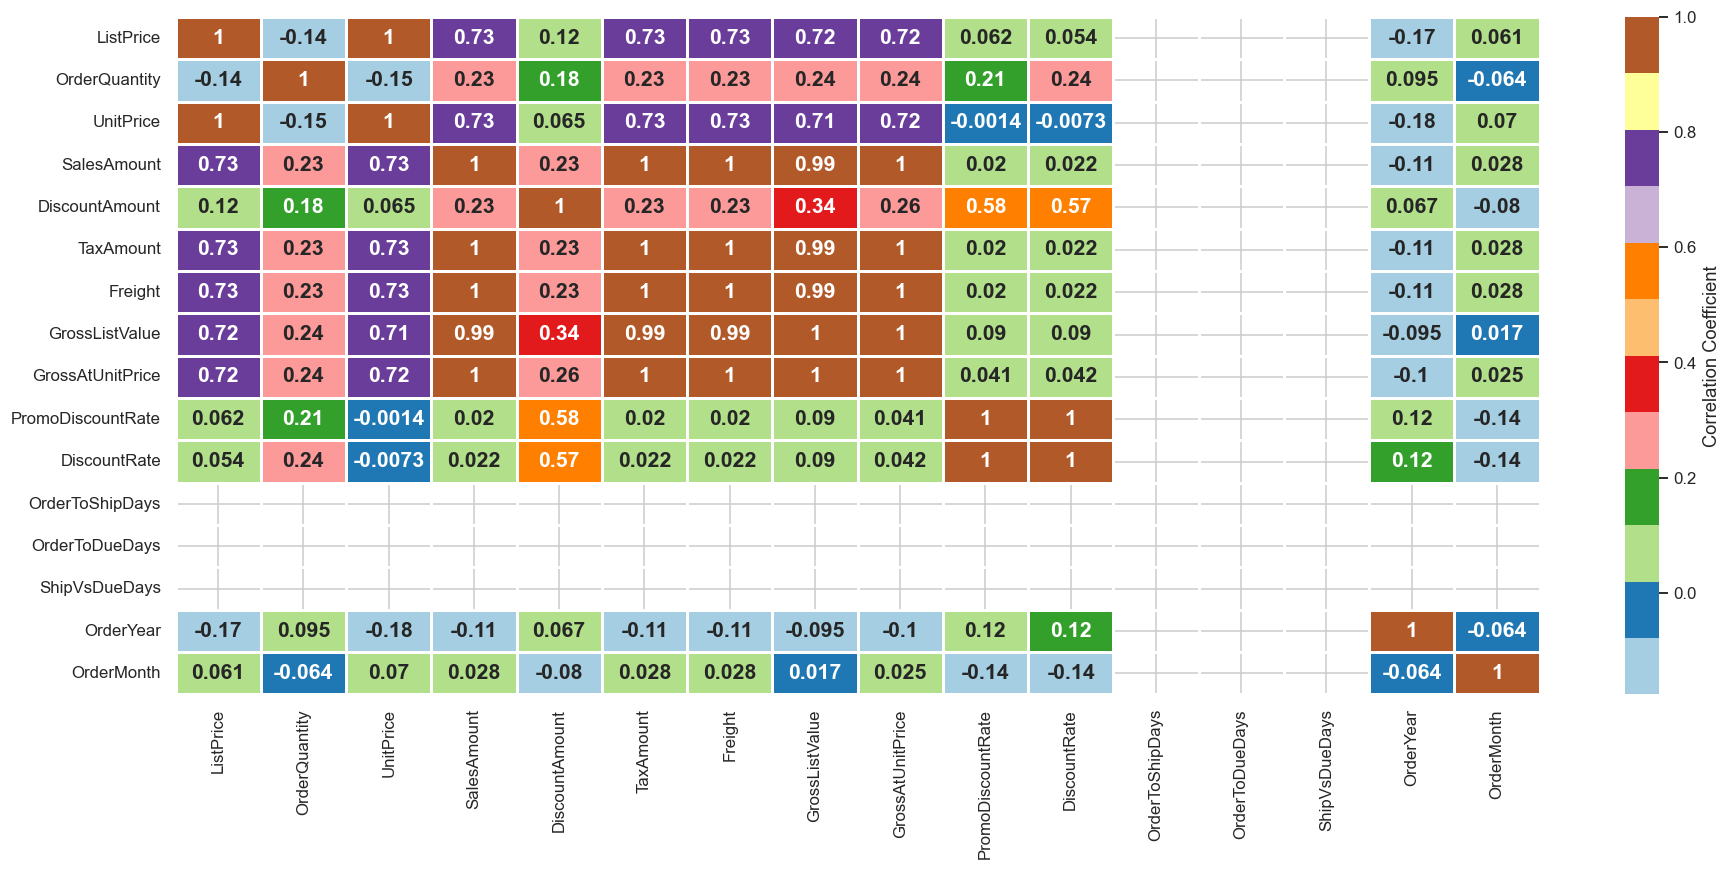

In [57]:
plt.figure(figsize=(20, 8))
sns.heatmap( data=df.corr(numeric_only=True),
annot=True, # annot=True instructs the my code to display the␣
            # numerical values within each cell of the plot
cmap="Paired", # stands for colored map, the paired is a color␣
            # with 10 distinct color types in it making it suitable for multiple␣
            # visualization
linewidths=0.8, # adjust line width between heatmap cells
cbar_kws={"label": "Correlation Coefficient"}, # customize␣
            # colorbar label
annot_kws={"fontsize": 14, "fontweight": "bold"}, # Increase font␣
            # size and weight
)
plt.show() # shows the heatmap chart

### Findings

**Correlation must be interpreted as association, not causation.**

- Freight and SalesAmount can be positively associated because larger transactions may naturally carry larger freight amounts; this does not mean freight causes sales.
- Financial variables such as SalesAmount, TaxAmount, Freight, and discount-related fields can be mechanically related because they are calculated from transaction values.
- For promotional analysis, the separate Spearman correlations between promotional discount rate and sales/quantity should be treated as descriptive evidence rather than causal estimates.


## 14 Key Findings

### Product performance
- Total recorded revenue is approximately **\$41.62 million**.
- **Bikes** generate approximately **80.83%** of revenue.
- **Mountain-200 Black, 38** is the highest-revenue product at approximately **$1.64 million**.
- **Long-Sleeve Logo Jersey, L** records the highest unit volume at approximately **3,394 units**.
- This difference shows why revenue and sales volume should be analyzed separately.

### Regional performance
- **Southwest** is the largest revenue-contributing region at approximately **22.87%** of total revenue.
- Canada and Northwest are the next largest contributors.
- Order-level statistical testing indicates significant differences in revenue distributions across regions, but the test does not establish why those differences exist.

### Promotion analysis
- **No Discount** accounts for most recorded sales.
- Among named discounted promotions, **Volume Discount 11-14** has the highest total revenue.
- The relationship between discounts and sales is descriptive; promotion profitability cannot be established without cost/margin data.

### Sales trends
- Recorded annual revenue rises across the available periods.
- 2013 is only a partial year, so its total should not be compared directly with full-year totals.
- Calendar-month patterns are observable, but the available history is insufficient for a strong seasonal claim.

### Operations
- Average order-to-ship time is **7 days**.
- Average order-to-due time is **12 days**.
- Shipments occur **5 days before due date on average**, with no observed late shipment lines.


## 15 Recommendations

### Product and inventory strategy
- Prioritize availability and inventory planning for high-revenue products and high-demand subcategories.
- Separate high-volume/low-value products from low-volume/high-value products when setting inventory priorities.
- Add product cost, margin, inventory-on-hand, and stockout data before making assortment or profitability decisions.

### Regional strategy
- Monitor Southwest, Canada, and Northwest closely because they contribute large shares of recorded revenue.
- Compare regional revenue with order count and average order value to understand whether differences come from order frequency or order size.
- Investigate regional differences using product mix, customer mix, promotion use, and fulfilment data.

### Promotion strategy
- Evaluate promotions using incremental sales, units, discount amount, gross margin, and customer/order behavior.
- Compare promoted products with comparable non-promoted periods/products before claiming that a promotion increased demand.
- Segment promotion analysis by category, product, and region.

### Time-series strategy
- Continue collecting complete monthly data before making strong seasonal forecasts.
- Compare the same calendar months across multiple complete years and control for overall growth.

### Operational strategy
- The observed 7-day order-to-ship process is highly consistent.
- Monitor future orders for shipments after due dates.
- Add actual delivery dates to distinguish warehouse/shipping performance from customer delivery performance.


## 16. Limitations

- The dataset is at transaction-line level. One order number can appear in multiple rows, so transaction-line counts should not be treated as unique order counts.
- The analysis contains sales revenue but does not contain product cost, gross margin, marketing spend, inventory levels, or return data. It cannot measure profitability.
- Actual delivery date is not available. Operational analysis measures shipment timing, not delivery completion or customer delivery experience.
- The time series may have incomplete monthly and yearly coverage. Zero or absent months may reflect missing data rather than true zero sales.
- Missing `Color` values were labelled as `Unknown`; they should not be interpreted as a specific product colour.
- Correlation measures association, not causation. Some financial measures appear structurally related and should not be interpreted as independent drivers.
- Customer demographics and customer-level identifiers are unavailable, so the analysis cannot evaluate customer segments, retention, or lifetime value.
- The dataset source and field definitions should be verified before making external business decisions.

# 17. Final Executive Summary

The analysis shows a revenue-concentrated retail business: **Bikes account for approximately 80.83% of revenue**, while the highest-volume products are generally lower-priced clothing and accessory items. This means revenue and unit demand should be managed as separate performance dimensions.

The **Southwest** is the largest revenue-contributing region at approximately **22.87%**. Order-level statistical testing provides evidence that revenue distributions differ across regions, but the test does not establish why. Product mix, order size, customer mix, promotion use, and fulfilment should be investigated to explain the differences.

Promotions require cautious interpretation. **Volume Discount 11-14** is the largest discounted promotion by total revenue, while the largest product-level promotional discounts are concentrated in selected Touring-1000 products. Observational correlations do not prove that discounts caused changes in sales.

Operationally, the dataset is unusually consistent: average order-to-ship time is **7 days**, average order-to-due time is **12 days**, and shipments occur **5 days before the due date on average**, with no observed late shipment lines. This measures shipment timing only; an actual delivery date would be needed to measure customer delivery performance.

Finally, the dataset does not contain product cost, gross margin, marketing spend, inventory, returns, or actual delivery dates. Therefore, the analysis can identify **sales performance and operational patterns**, but it cannot determine true profitability, incremental promotion impact, customer lifetime value, or delivery experience.